<a href="https://colab.research.google.com/github/Yiiize/MSSP6070/blob/main/WeeklyModules/Week08/PARTICIPATION_ACTIVITY_Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import userdata
import os

github_token = userdata.get('Git_Key')
owner = 'Yiiize' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
import subprocess
subprocess.run(['git', 'clone', clone_url])

# Navigate into the cloned repository directory (optional, but often useful)
os.chdir(repository)
print(f"Changed directory to: {os.getcwd()}")


Changed directory to: /content/MSSP6070


In [14]:
import pandas as pd
import os

# Read the InternetSales.csv file with 'latin1' encoding
file_path = os.path.join(data_path, 'InternetSales.csv')
try:
  internet_sales_df = pd.read_csv(file_path, encoding='latin1')
  display(internet_sales_df.head())
except FileNotFoundError:
  print(f"Error: {file_path} not found.")
except Exception as e:
  print(f"An error occurred while reading the file: {e}")

/tmp/ipython-input-2550062522.py:7: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  internet_sales_df = pd.read_csv(file_path, encoding='latin1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


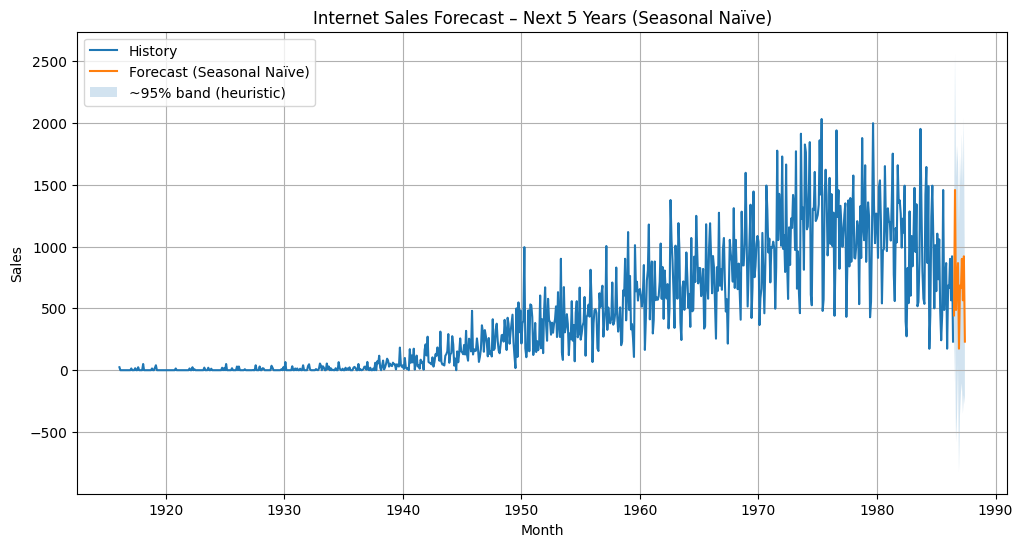

=== 年度汇总（历史 + 预测） ===


,history,forecast
1916-01-01,24.0,NaN
1917-01-01,54.0,NaN
1918-01-01,64.0,NaN
1919-01-01,61.0,NaN
1920-01-01,14.0,NaN
...,...,...
1987-01-01,NaN,3967.0
1988-01-01,NaN,0.0
1989-01-01,NaN,0.0
1990-01-01,NaN,0.0


=== 产品销售摘要 Top 10（历史总额） ===


,total_sales,mean_per_txn,transactions
ProductKey,,,
477,25675,6.049717,4244
480,19370,6.070197,3191
528,17019,5.498869,3095
529,15762,6.633838,2376
225,14329,6.542922,2190
214,14310,6.417040,2230
222,13245,6.232941,2125
217,12981,6.225899,2085
479,11648,6.803738,1712



=== 作业答案 ===
2) 上图给出未来5年的Internet Sales预测（季节性朴素法）。
3) 基于摘要统计，历史总销售额最高的产品是：477（总销售额 = 25,675.00）。


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你已经有 internet_sales_df
df = internet_sales_df.copy()
df.columns = [c.strip() for c in df.columns]

# ---- 识别/设置列名（必要时手动改）----
date_col    = next(c for c in df.columns if "Date" in c or "date" in c)
sales_col   = next(c for c in df.columns if "Sales" in c or "Amount" in c or "Revenue" in c)
product_col = next((c for c in df.columns if "Product" in c or "Item" in c), None)

df[date_col]  = pd.to_datetime(df[date_col], errors="coerce")
df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")
df = df.dropna(subset=[date_col, sales_col]).sort_values(date_col)

# ---- 月度汇总 ----
ts = (df.set_index(date_col)
        .resample("MS")[sales_col]
        .sum()
        .rename("sales"))

# ---- “季节性朴素法”5年预测：预测每个月 = 去年同月的值 ----
future_idx = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=12*5, freq="MS")

# 构造一个带未来索引的拼接序列以便使用 shift(12)
tmp = pd.concat([ts, pd.Series(index=future_idx, dtype=float, name="sales")])
forecast = tmp.shift(12).loc[future_idx].rename("sales_forecast")

# 简单置信带（可选）：用过去同月的历史标准差做一个“经验区间”
same_month_std = ts.groupby(ts.index.month).std().reindex(forecast.index.month).values
lower = (forecast.values - 1.96 * same_month_std)
upper = (forecast.values + 1.96 * same_month_std)

# ---- 图：历史 + 预测 ----
plt.figure(figsize=(12,6))
plt.plot(ts.index, ts.values, label="History")
plt.plot(forecast.index, forecast.values, label="Forecast (Seasonal Naïve)")
plt.fill_between(forecast.index, lower, upper, alpha=0.2, label="~95% band (heuristic)")
plt.title("Internet Sales Forecast – Next 5 Years (Seasonal Naïve)")
plt.xlabel("Month"); plt.ylabel("Sales"); plt.legend(); plt.grid(True)
plt.show()

# 年度汇总（历史 + 预测）
annual_hist = ts.resample("YS").sum().rename("history")
annual_fc   = forecast.resample("YS").sum().rename("forecast")
annual_table = pd.concat([annual_hist, annual_fc], axis=1)
print("=== 年度汇总（历史 + 预测） ===")
display(annual_table)

# ---- 产品摘要统计：哪个产品销售额最高 ----
if product_col is not None:
    by_prod = (df.groupby(product_col)[sales_col]
                 .agg(total_sales="sum", mean_per_txn="mean", transactions="count")
                 .sort_values("total_sales", ascending=False))
    print("=== 产品销售摘要 Top 10（历史总额） ===")
    display(by_prod.head(10))

    top_name  = by_prod.index[0]
    top_value = by_prod.iloc[0]["total_sales"]
    print("\n=== 作业答案 ===")
    print("2) 上图给出未来5年的Internet Sales预测（季节性朴素法）。")
    print(f"3) 基于摘要统计，历史总销售额最高的产品是：{top_name}（总销售额 = {top_value:,.2f}）。")
else:
    print("未检测到产品列，需手动设置 product_col 才能输出按产品摘要统计。")
